In [1]:

#from torch.utils.data import DataLoader
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# === Load data ===
df = pd.read_parquet("../data/measuring-hate-speech.parquet")
df = df.dropna(subset=['text'])

numerical_cols = ['sentiment', 'respect', 'insult', 'humiliate', 'status',
                  'dehumanize', 'attack_defend', 'hatespeech']
binary_cols = ['target_race', 'target_religion', 'target_origin', 'target_gender',
               'target_sexuality']

In [3]:
print(df.shape)

(135556, 131)


In [4]:
columns_to_check = [
    'sentiment', 'respect', 'insult', 'humiliate', 'status',
    'violence', 'dehumanize', 'genocide', 'attack_defend', 'hatespeech',
    'target_race', 'target_religion', 'target_origin', 'target_gender',
    'target_sexuality', 'target_age', 'target_disability', 'text'
]

for col in columns_to_check:
    if pd.api.types.is_numeric_dtype(df[col]):
        print(f"{col}: min = {df[col].min()}, max = {df[col].max()}")
    else:
        print(f"{col}: not numeric (type = {df[col].dtype})")


sentiment: min = 0.0, max = 4.0
respect: min = 0.0, max = 4.0
insult: min = 0.0, max = 4.0
humiliate: min = 0.0, max = 4.0
status: min = 0.0, max = 4.0
violence: min = 0.0, max = 4.0
dehumanize: min = 0.0, max = 4.0
genocide: min = 0.0, max = 4.0
attack_defend: min = 0.0, max = 4.0
hatespeech: min = 0.0, max = 2.0
target_race: min = False, max = True
target_religion: min = False, max = True
target_origin: min = False, max = True
target_gender: min = False, max = True
target_sexuality: min = False, max = True
target_age: min = False, max = True
target_disability: min = False, max = True
text: not numeric (type = object)


In [5]:
# List of the columns you're interested in
columns_to_keep = [
    "hatespeech", "hate_speech_score", "text", "sentiment", "respect", "insult", "humiliate", "status", "violence",
    "dehumanize", "genocide", "attack_defend", "hatespeech",
    "target_race", "target_religion", "target_origin", "target_gender",
    "target_sexuality", "target_age", "target_disability"
]

# Create a filtered DataFrame
filtered_df = df[columns_to_keep]

# Show the first 20 rows as a table
print(filtered_df.head(20).to_string(index=False))

 hatespeech  hate_speech_score                                                                                                                                                                                                                                                                                                                                                              text  sentiment  respect  insult  humiliate  status  violence  dehumanize  genocide  attack_defend  hatespeech  target_race  target_religion  target_origin  target_gender  target_sexuality  target_age  target_disability
        0.0              -3.90                                                                                                    Yes indeed. She sort of reminds me of the elder lady that played the part in the movie "Titanic" who was telling her story!!! And I wouldn't have wanted to cover who I really am!! I would be proud!!!! WE should be proud of our race no matter what it is!!        0.0     

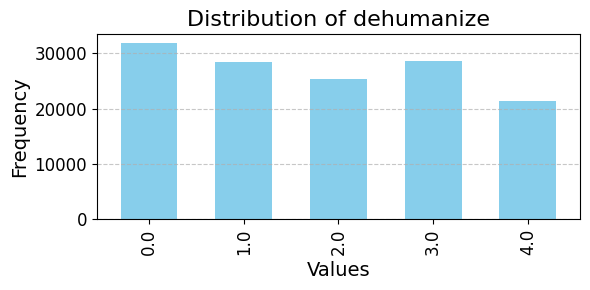

In [6]:
plt.figure(figsize=(6, 3))
# Plot with smaller bars by adjusting bar width
df['dehumanize'].value_counts().sort_index().plot(
    kind='bar',
    color='skyblue',
    width=0.6  # makes bars thinner
)

plt.title('Distribution of dehumanize', fontsize=16)
plt.xlabel('Values', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

# Adjust tick label size
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Make the grid lines thinner and more transparent
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

# Save the figure as a high-resolution JPG
plt.savefig('dehumanize_distribution.jpg', dpi=300)
plt.show()


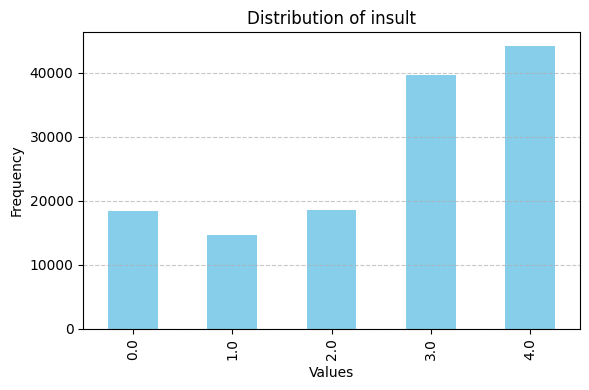

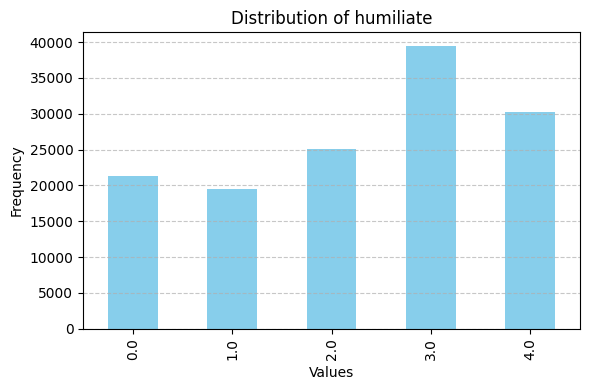

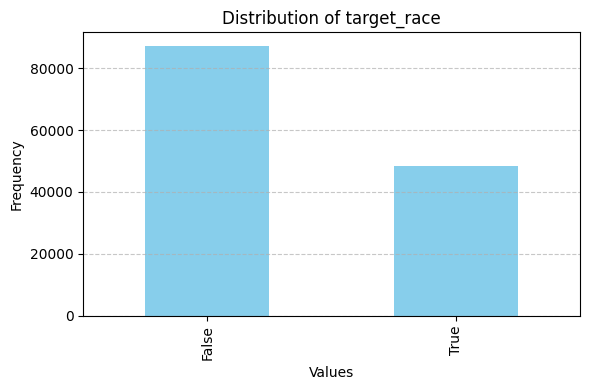

In [7]:
# Specify column names directly
cols = ['insult', 'humiliate', 'target_race']

for col in cols:
    plt.figure(figsize=(6, 4))
    df[col].value_counts().sort_index().plot(kind='bar', color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel('Values')
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
